# COMP9517 2026 T2 — Lab 3

## KNN vs. Decision Tree vs. SGD on the Chinese MNIST dataset

This notebook implements and compares the performance of three classifiers on the **Chinese MNIST** dataset:

- **K-Nearest Neighbours (KNN)** — `k = 3`
- **Decision Tree (DT)** — default settings
- **Stochastic Gradient Descent (SGD)** — `max_iter = 250`

The Chinese MNIST dataset contains **15,000** grayscale images (**64 × 64** pixels) of **15** handwritten Chinese number characters (1,000 images per class).

We follow the steps described in the lab specification:

1. Import relevant packages
2. Load and explore the dataset
3. Split and sample the dataset (stratified) — 5,000 train / 1,000 test, then repeat with 10,000 train
4. Reshape the data
5. Initialise each classifier
6. Fit each classifier on the training data
7. Evaluate each trained model on the testing data
8. Report accuracy, precision, recall, F1-score and the confusion matrix

## Step 1: Import relevant packages

We mainly use **scikit-learn** for the classifiers and evaluation metrics, **OpenCV** (`cv2`) to read the images, and `numpy` / `pandas` / `matplotlib` / `seaborn` for data handling and visualisation.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier

# Data splitting
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline
sns.set_theme(style="whitegrid")

print("OpenCV version :", cv2.__version__)
import sklearn
print("scikit-learn   :", sklearn.__version__)

OpenCV version : 4.13.0
scikit-learn   : 1.9.0


## Step 2: Download the dataset and explore it

The dataset (downloaded from WebCMS3 / Kaggle) is organised as follows:

```
Chinese_MNIST_Dataset/
├── chinese_mnist.csv      # index / label file
└── data/                  # 15,000 images named input_{suite_id}_{sample_id}_{code}.jpg
```

The `chinese_mnist.csv` file provides, for every image, the `suite_id`, `sample_id` and `code`, from which the **image file name** is reconstructed, plus the ground-truth `value` and Chinese `character`.

Below we check how many images/labels there are, the image size, the number of classes and the number of images per class, and we display a few example images for each label.

In [2]:
# Paths to the dataset (adjust if your dataset lives elsewhere)
csv_path = "Chinese_MNIST_Dataset/chinese_mnist.csv"
image_dir = "Chinese_MNIST_Dataset/data"

# Load the label / index file
labels = pd.read_csv(csv_path)

# Reconstruct the image file name and full path for every row
# File name pattern: input_{suite_id}_{sample_id}_{code}.jpg
labels["file_name"] = (
    "input_"
    + labels["suite_id"].astype(str)
    + "_"
    + labels["sample_id"].astype(str)
    + "_"
    + labels["code"].astype(str)
    + ".jpg"
)
labels["file_path"] = labels["file_name"].apply(lambda f: os.path.join(image_dir, f))

print("First rows of the index file:")
labels.head()

First rows of the index file:


,suite_id,sample_id,code,value,character,file_name,file_path
0,1,1,10,9,九,input_1_1_10.jpg,Chinese_MNIST_Dataset/data/input_1_1_10.jpg
1,1,10,10,9,九,input_1_10_10.jpg,Chinese_MNIST_Dataset/data/input_1_10_10.jpg
2,1,2,10,9,九,input_1_2_10.jpg,Chinese_MNIST_Dataset/data/input_1_2_10.jpg
3,1,3,10,9,九,input_1_3_10.jpg,Chinese_MNIST_Dataset/data/input_1_3_10.jpg
4,1,4,10,9,九,input_1_4_10.jpg,Chinese_MNIST_Dataset/data/input_1_4_10.jpg


In [3]:
# Basic statistics about the dataset
n_images = len(labels)
n_classes = labels["code"].nunique()

print(f"Total number of images / labels : {n_images}")
print(f"Number of classes               : {n_classes}")

# Verify all image files exist
missing = (~labels["file_path"].apply(os.path.exists)).sum()
print(f"Missing image files             : {missing}")

# Image size (read one image)
sample_img = cv2.imread(labels.loc[0, "file_path"], cv2.IMREAD_GRAYSCALE)
print(f"Image size (height x width)     : {sample_img.shape}")
print(f"Pixel value range               : [{sample_img.min()}, {sample_img.max()}]  (dtype: {sample_img.dtype})")

# Number of images per class
print("\nNumber of images per class:")
class_counts = (
    labels.groupby(["code", "value", "character"]).size().reset_index(name="count")
)
class_counts

Total number of images / labels : 15000
Number of classes               : 15
Missing image files             : 0
Image size (height x width)     : (64, 64)
Pixel value range               : [0, 206]  (dtype: uint8)

Number of images per class:


,code,value,character,count
0,1,0,零,1000
1,2,1,一,1000
2,3,2,二,1000
3,4,3,三,1000
4,5,4,四,1000
5,6,5,五,1000
6,7,6,六,1000
7,8,7,七,1000
8,9,8,八,1000
9,10,9,九,1000


/tmp/ipykernel_8417/3990839652.py:14: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/3990839652.py:14: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/3990839652.py:14: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/3990839652.py:14: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/3990839652.py:14: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/3990839652.py:14: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/3990839652.py:14: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}

/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from fon

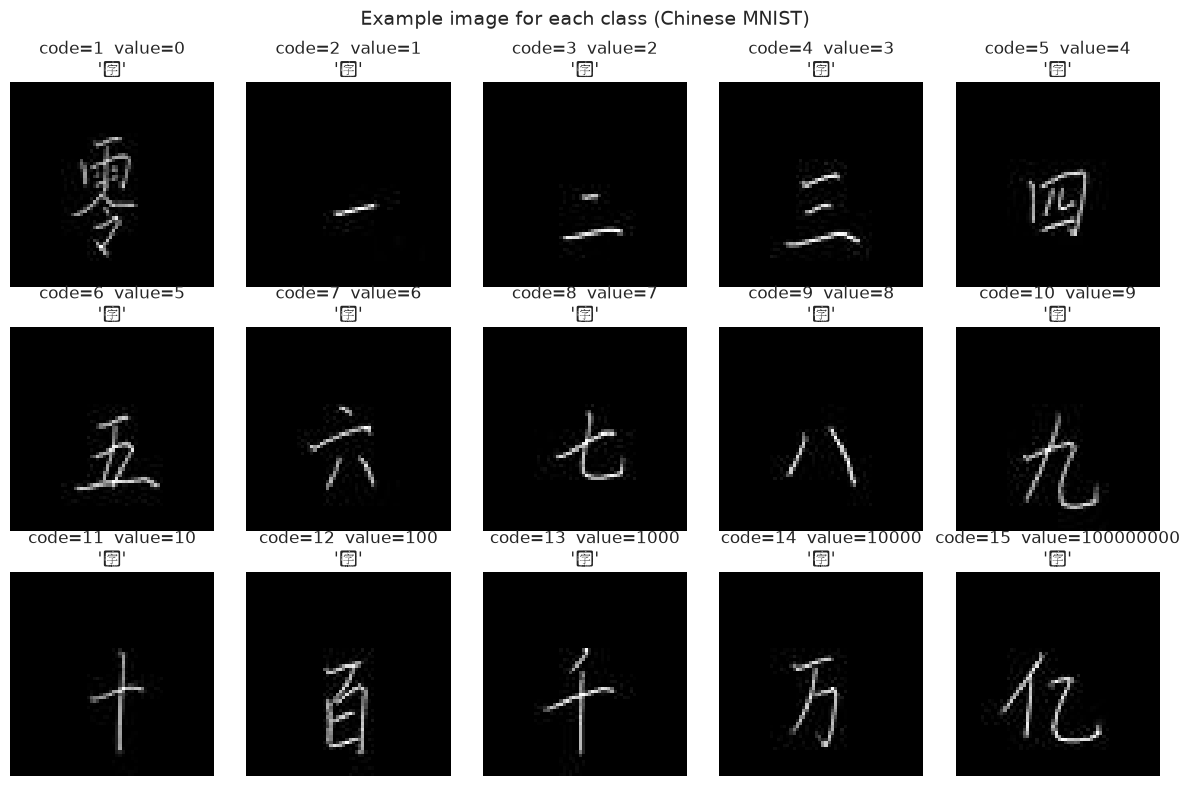

In [4]:
# Display one example image for each of the 15 classes
code_to_char = dict(zip(class_counts["code"], class_counts["character"]))
code_to_value = dict(zip(class_counts["code"], class_counts["value"]))

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, code in zip(axes.ravel(), sorted(labels["code"].unique())):
    row = labels[labels["code"] == code].iloc[0]
    img = cv2.imread(row["file_path"], cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"code={code}  value={code_to_value[code]}\n'{code_to_char[code]}'")
    ax.axis("off")

fig.suptitle("Example image for each class (Chinese MNIST)", fontsize=14)
plt.tight_layout()
plt.show()

/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from fon

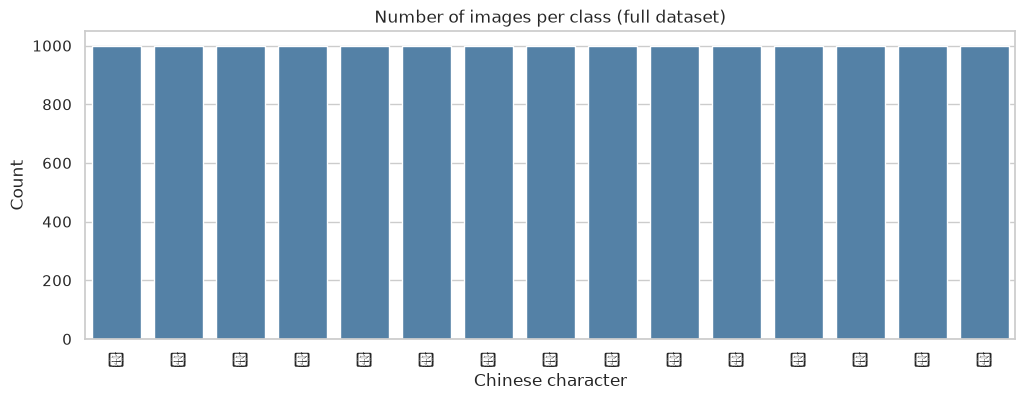

In [5]:
# Bar plot of the class distribution (should be perfectly balanced: 1000 per class)
plt.figure(figsize=(12, 4))
sns.barplot(data=class_counts, x="character", y="count", color="steelblue")
plt.title("Number of images per class (full dataset)")
plt.xlabel("Chinese character")
plt.ylabel("Count")
plt.show()

## Step 3: Split and sample the dataset

To reduce the computational cost we work with a subset of the 15,000 images:

- **1,000** randomly sampled images for **testing**
- **5,000** randomly sampled images for **training** (later doubled to **10,000**)

Sampling is done in a **stratified** way so that each of the 15 classes is (approximately) equally represented:

- Training (5,000): ≈ 333 images per class
- Training (10,000): ≈ 666 images per class
- Testing (1,000): ≈ 66 images per class

To avoid **data leakage**, the test set is carved out first and the training subsets are drawn **only** from the remaining images, guaranteeing that training and testing sets are completely disjoint. The **same 1,000-image test set** is reused for both the 5,000 and 10,000 training experiments so the comparison is fair.

In [6]:
# We use "code" (1..15) as the class label.
y_all = labels["code"]

# 1) Carve out a stratified 1,000-image TEST set first.
#    The remaining 14,000 images form the pool we draw the training subsets from,
#    which guarantees train/test are completely disjoint (no leakage).
pool_df, test_df = train_test_split(
    labels,
    test_size=1000,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

# 2) From the remaining pool, draw a stratified 5,000-image training set ...
train_df_5000, _ = train_test_split(
    pool_df,
    train_size=5000,
    stratify=pool_df["code"],
    random_state=RANDOM_STATE,
)

# 3) ... and a stratified 10,000-image training set (used later).
train_df_10000, _ = train_test_split(
    pool_df,
    train_size=10000,
    stratify=pool_df["code"],
    random_state=RANDOM_STATE,
)

print(f"Test set size            : {len(test_df)}")
print(f"Training set size (small): {len(train_df_5000)}")
print(f"Training set size (large): {len(train_df_10000)}")

# Sanity check: no overlap between training and testing sets
overlap_5000 = set(train_df_5000["file_name"]) & set(test_df["file_name"])
overlap_10000 = set(train_df_10000["file_name"]) & set(test_df["file_name"])
print(f"\nTrain/Test overlap (5,000 vs test) : {len(overlap_5000)} images")
print(f"Train/Test overlap (10,000 vs test): {len(overlap_10000)} images")

print("\nImages per class — training (5,000):")
print(train_df_5000["code"].value_counts().sort_index().to_string())
print("\nImages per class — testing (1,000):")
print(test_df["code"].value_counts().sort_index().to_string())

Test set size            : 1000
Training set size (small): 5000
Training set size (large): 10000

Train/Test overlap (5,000 vs test) : 0 images
Train/Test overlap (10,000 vs test): 0 images

Images per class — training (5,000):
code
1     334
2     333
3     333
4     333
5     333
6     334
7     333
8     333
9     333
10    334
11    333
12    334
13    333
14    334
15    333

Images per class — testing (1,000):
code
1     66
2     67
3     67
4     67
5     67
6     66
7     67
8     67
9     67
10    66
11    67
12    66
13    67
14    66
15    67


## Step 4: Perform necessary data reshaping

The scikit-learn classifiers expect each sample to be a **1-D feature vector**. Each Chinese MNIST image is 64 × 64 pixels, so we flatten it into a vector of length **64 × 64 = 4096**.

The helper below reads every image (as grayscale) for a given subset and returns:

- `X`: a 2-D array of shape `(n_samples, 4096)`
- `y`: the corresponding class labels (the `code` column)

In [7]:
IMG_SIZE = 64  # each image is 64 x 64


def load_dataset(df):
    """Read every image referenced by `df`, flatten it, and return (X, y).

    X : np.ndarray, shape (n_samples, IMG_SIZE * IMG_SIZE)
    y : np.ndarray, shape (n_samples,)  -- the class label (code)
    """
    X = np.empty((len(df), IMG_SIZE * IMG_SIZE), dtype=np.float32)
    for i, path in enumerate(df["file_path"].values):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # (64, 64)
        X[i] = img.reshape(-1)                          # flatten to (4096,)
    y = df["code"].to_numpy()
    return X, y


# Build the arrays for every subset
t0 = time.time()
X_train_5000, y_train_5000 = load_dataset(train_df_5000)
X_train_10000, y_train_10000 = load_dataset(train_df_10000)
X_test, y_test = load_dataset(test_df)
print(f"Loaded and reshaped all subsets in {time.time() - t0:.1f} s\n")

print("Shapes after reshaping:")
print(f"  X_train (5,000)  : {X_train_5000.shape},  y: {y_train_5000.shape}")
print(f"  X_train (10,000) : {X_train_10000.shape}, y: {y_train_10000.shape}")
print(f"  X_test  (1,000)  : {X_test.shape},   y: {y_test.shape}")

Loaded and reshaped all subsets in 0.6 s

Shapes after reshaping:
  X_train (5,000)  : (5000, 4096),  y: (5000,)
  X_train (10,000) : (10000, 4096), y: (10000,)
  X_test  (1,000)  : (1000, 4096),   y: (1000,)


## Steps 5–8: Initialise, fit, evaluate and report each classifier

For every classifier we:

- **Step 5 — Initialise** the classifier object:
  - **KNN**: `n_neighbors = 3` (i.e. `k = 3`)
  - **Decision Tree**: default settings
  - **SGD**: `max_iter = 250`
  - all other parameters left at their defaults
- **Step 6 — Fit** the classifier on the training data with `fit()`
- **Step 7 — Predict** on the test data with `predict()`
- **Step 8 — Report** accuracy, precision, recall, F1-score (macro- and weighted-averaged, plus a per-class `classification_report`) and the **confusion matrix**

The function below performs all four steps for the three classifiers on a given training set and returns a summary table of the metrics.

In [8]:
def build_classifiers():
    """Step 5: initialise the three classifiers with the required settings."""
    return {
        "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "SGD (max_iter=250)": SGDClassifier(max_iter=250, random_state=RANDOM_STATE),
    }


# Ordered class labels and their Chinese characters (for confusion-matrix ticks)
class_labels = sorted(labels["code"].unique())
class_names = [f"{code_to_char[c]}\n({code_to_value[c]})" for c in class_labels]


def evaluate_classifier(name, clf, X_train, y_train, X_test, y_test):
    """Steps 6-8 for a single classifier: fit, predict, report metrics + confusion matrix."""
    # Step 6: fit
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    # Step 7: predict
    y_pred = clf.predict(X_test)

    # Step 8: metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print("=" * 70)
    print(f"Classifier: {name}   |   training samples: {len(X_train)}   |   fit time: {train_time:.2f}s")
    print("=" * 70)
    print(f"Accuracy            : {acc:.4f}")
    print(f"Precision (macro)   : {prec:.4f}")
    print(f"Recall    (macro)   : {rec:.4f}")
    print(f"F1-score  (macro)   : {f1:.4f}")
    print("\nPer-class classification report:")
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_labels], zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"Confusion matrix — {name}  ({len(X_train)} training images)")
    plt.tight_layout()
    plt.show()

    return {
        "Classifier": name,
        "Train size": len(X_train),
        "Accuracy": acc,
        "Precision (macro)": prec,
        "Recall (macro)": rec,
        "F1-score (macro)": f1,
    }


def run_experiment(X_train, y_train, X_test, y_test, experiment_name):
    """Run steps 5-8 for all three classifiers and return a summary DataFrame."""
    print("#" * 70)
    print(f"# EXPERIMENT: {experiment_name}")
    print("#" * 70)
    results = []
    for name, clf in build_classifiers().items():
        results.append(evaluate_classifier(name, clf, X_train, y_train, X_test, y_test))
    return pd.DataFrame(results)

### Experiment A — 5,000 training images / 1,000 test images

######################################################################
# EXPERIMENT: 5,000 training images
######################################################################


Classifier: KNN (k=3)   |   training samples: 5000   |   fit time: 0.01s
Accuracy            : 0.3510
Precision (macro)   : 0.5631
Recall    (macro)   : 0.3504
F1-score  (macro)   : 0.3582

Per-class classification report:
              precision    recall  f1-score   support

           1       0.89      0.61      0.72        66
           2       0.15      0.97      0.26        67
           3       0.21      0.34      0.26        67
           4       0.30      0.30      0.30        67
           5       0.61      0.21      0.31        67
           6       0.55      0.09      0.16        66
           7       0.28      0.22      0.25        67
           8       0.57      0.24      0.34        67
           9       0.95      0.85      0.90        67
          10       0.60      0.14      0.22        66
          11       0.44      0.51      0.47        67
          12       0.86      0.18      0.30        66
          13       0.60      0.27      0.37        67
          14       0

/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}

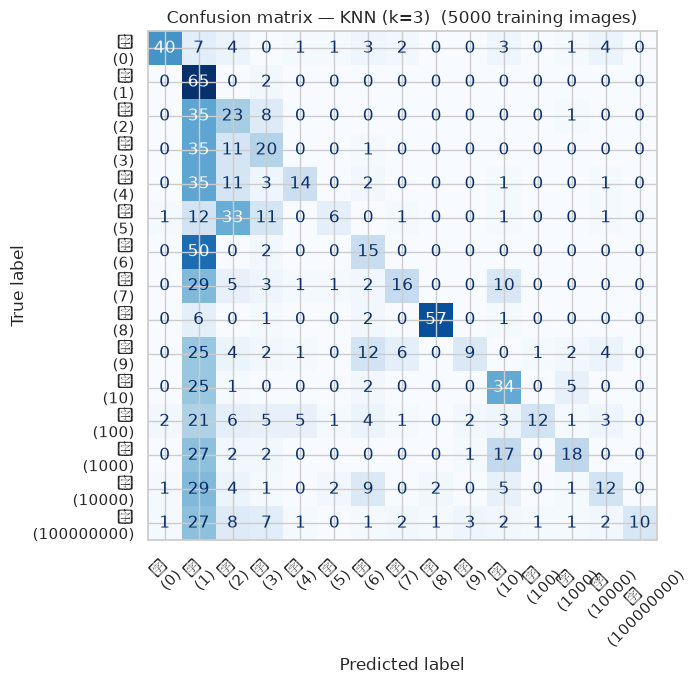

Classifier: Decision Tree   |   training samples: 5000   |   fit time: 2.03s
Accuracy            : 0.2880
Precision (macro)   : 0.2813
Recall    (macro)   : 0.2877
F1-score  (macro)   : 0.2824

Per-class classification report:
              precision    recall  f1-score   support

           1       0.46      0.38      0.42        66
           2       0.60      0.76      0.67        67
           3       0.26      0.27      0.26        67
           4       0.19      0.22      0.21        67
           5       0.26      0.22      0.24        67
           6       0.26      0.23      0.24        66
           7       0.19      0.18      0.19        67
           8       0.25      0.22      0.24        67
           9       0.29      0.30      0.29        67
          10       0.15      0.17      0.16        66
          11       0.44      0.55      0.49        67
          12       0.18      0.18      0.18        66
          13       0.30      0.31      0.31        67
          14    

/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}

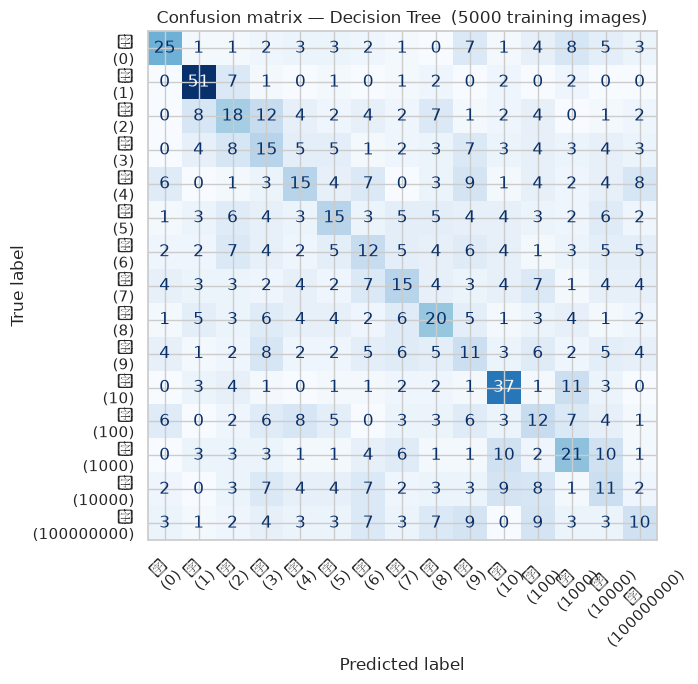

/workspace/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

Classifier: SGD (max_iter=250)   |   training samples: 5000   |   fit time: 24.89s
Accuracy            : 0.2970
Precision (macro)   : 0.3058
Recall    (macro)   : 0.2969
F1-score  (macro)   : 0.2937

Per-class classification report:
              precision    recall  f1-score   support

           1       0.56      0.58      0.57        66
           2       0.68      0.45      0.54        67
           3       0.21      0.13      0.17        67
           4       0.32      0.30      0.31        67
           5       0.32      0.36      0.34        67
           6       0.14      0.11      0.12        66
           7       0.26      0.13      0.18        67
           8       0.31      0.25      0.28        67
           9       0.33      0.31      0.32        67
          10       0.10      0.12      0.11        66
          11       0.37      0.55      0.45        67
          12       0.20      0.38      0.26        66
          13       0.29      0.36      0.32        67
          

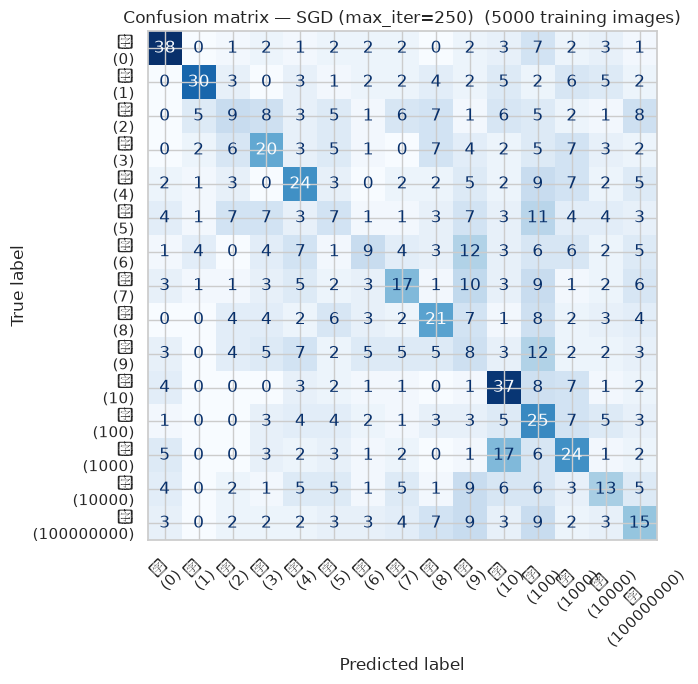

In [9]:
results_5000 = run_experiment(
    X_train_5000, y_train_5000, X_test, y_test,
    experiment_name="5,000 training images",
)

### Experiment B — 10,000 training images / 1,000 test images

Now we **double** the training set from 5,000 to 10,000 images (keeping the same 1,000 test images) and repeat the experiment to see whether the extra training data improves classification performance.

######################################################################
# EXPERIMENT: 10,000 training images
######################################################################


Classifier: KNN (k=3)   |   training samples: 10000   |   fit time: 0.04s
Accuracy            : 0.4350
Precision (macro)   : 0.6019
Recall    (macro)   : 0.4345
F1-score  (macro)   : 0.4439

Per-class classification report:
              precision    recall  f1-score   support

           1       0.88      0.67      0.76        66
           2       0.19      0.97      0.32        67
           3       0.27      0.45      0.34        67
           4       0.40      0.43      0.41        67
           5       0.86      0.36      0.51        67
           6       0.62      0.15      0.24        66
           7       0.31      0.25      0.28        67
           8       0.50      0.27      0.35        67
           9       0.89      0.96      0.92        67
          10       0.61      0.21      0.31        66
          11       0.49      0.61      0.55        67
          12       0.89      0.26      0.40        66
          13       0.66      0.31      0.42        67
          14       

/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}

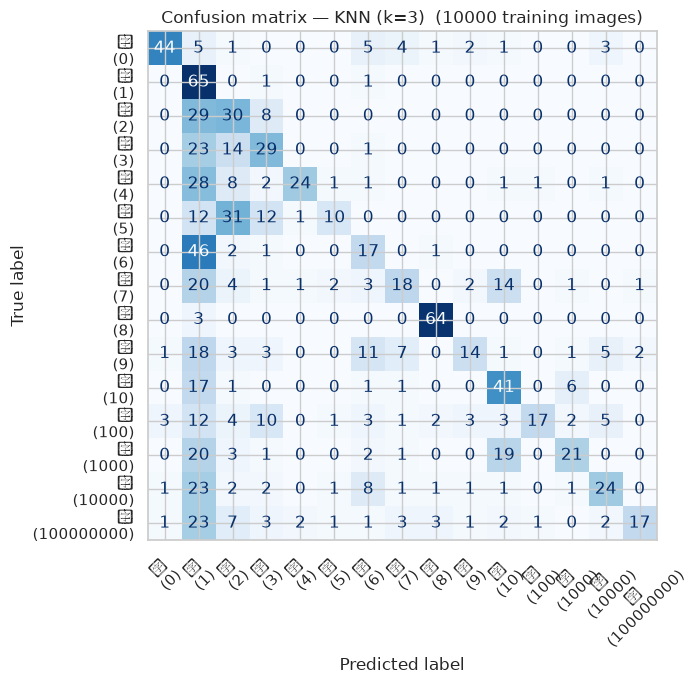

Classifier: Decision Tree   |   training samples: 10000   |   fit time: 4.58s
Accuracy            : 0.3010
Precision (macro)   : 0.2998
Recall    (macro)   : 0.3007
F1-score  (macro)   : 0.2994

Per-class classification report:
              precision    recall  f1-score   support

           1       0.49      0.41      0.45        66
           2       0.65      0.73      0.69        67
           3       0.39      0.42      0.40        67
           4       0.23      0.19      0.21        67
           5       0.33      0.30      0.31        67
           6       0.29      0.24      0.26        66
           7       0.22      0.22      0.22        67
           8       0.14      0.15      0.14        67
           9       0.42      0.46      0.44        67
          10       0.20      0.21      0.20        66
          11       0.30      0.31      0.31        67
          12       0.23      0.24      0.24        66
          13       0.26      0.28      0.27        67
          14   

/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}

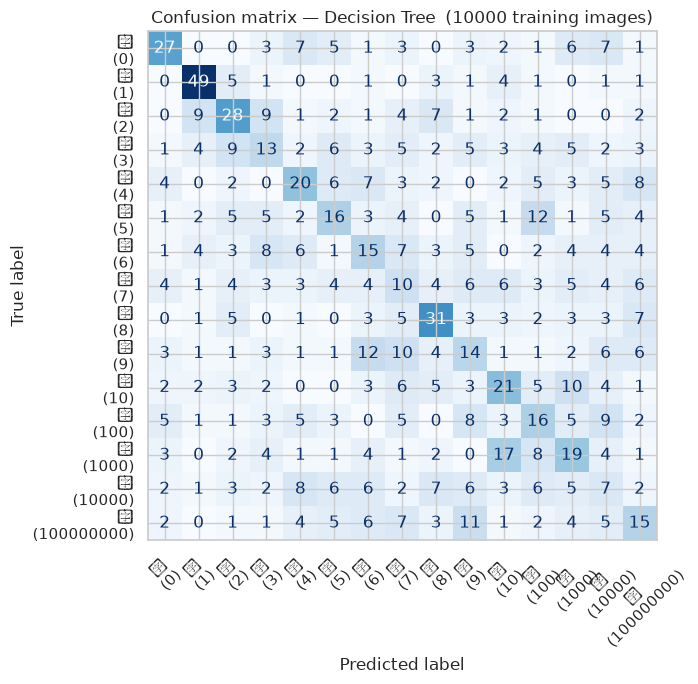

Classifier: SGD (max_iter=250)   |   training samples: 10000   |   fit time: 59.06s
Accuracy            : 0.3370
Precision (macro)   : 0.3515
Recall    (macro)   : 0.3370
F1-score  (macro)   : 0.3333

Per-class classification report:
              precision    recall  f1-score   support

           1       0.57      0.47      0.52        66
           2       0.63      0.40      0.49        67
           3       0.31      0.27      0.29        67
           4       0.39      0.22      0.29        67
           5       0.28      0.36      0.31        67
           6       0.25      0.44      0.32        66
           7       0.28      0.16      0.21        67
           8       0.32      0.28      0.30        67
           9       0.48      0.45      0.47        67
          10       0.22      0.23      0.23        66
          11       0.39      0.63      0.48        67
          12       0.23      0.26      0.24        66
          13       0.29      0.43      0.35        67
         

/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8417/2489158206.py:47: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}

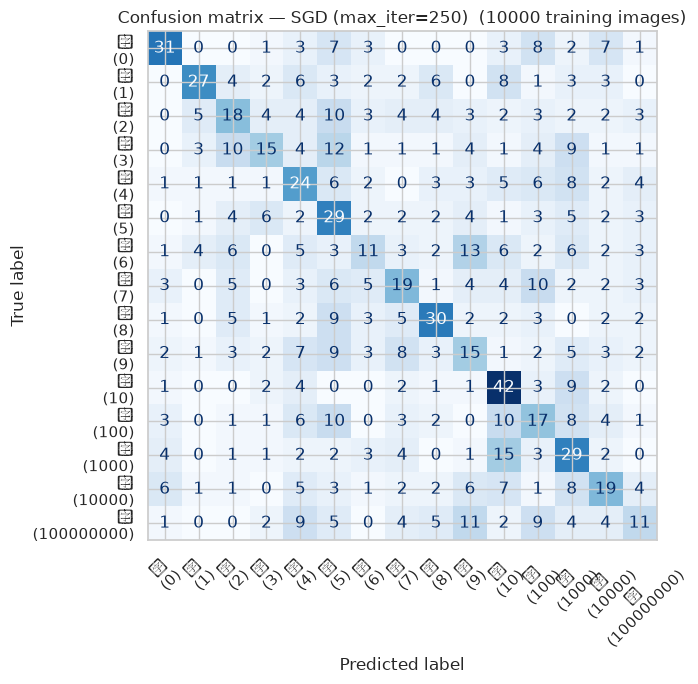

In [10]:
results_10000 = run_experiment(
    X_train_10000, y_train_10000, X_test, y_test,
    experiment_name="10,000 training images",
)

## Summary and comparison

The table and chart below bring together the metrics of all three classifiers for both training-set sizes, so we can directly compare their performance and see the effect of doubling the amount of training data.

In [11]:
# Combine both experiments into one summary table
summary = pd.concat([results_5000, results_10000], ignore_index=True)
summary_display = summary.copy()
for col in ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"]:
    summary_display[col] = summary_display[col].map(lambda v: f"{v:.4f}")
print("Combined summary of all metrics:")
summary_display

Combined summary of all metrics:


,Classifier,Train size,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,KNN (k=3),5000,0.3510,0.5631,0.3504,0.3582
1,Decision Tree,5000,0.2880,0.2813,0.2877,0.2824
2,SGD (max_iter=250),5000,0.2970,0.3058,0.2969,0.2937
3,KNN (k=3),10000,0.4350,0.6019,0.4345,0.4439
4,Decision Tree,10000,0.3010,0.2998,0.3007,0.2994
5,SGD (max_iter=250),10000,0.3370,0.3515,0.3370,0.3333


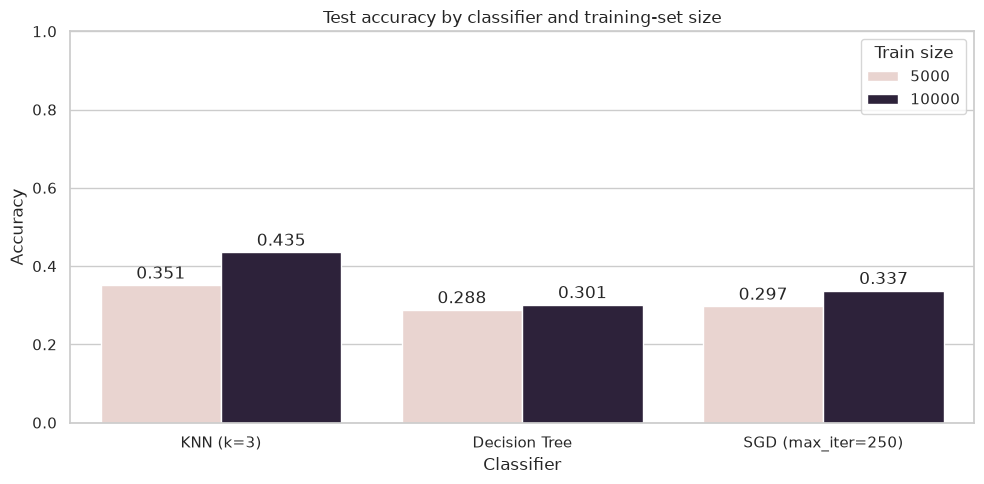

In [12]:
# Grouped bar chart: accuracy of each classifier for the two training sizes
plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="Classifier", y="Accuracy", hue="Train size")
plt.title("Test accuracy by classifier and training-set size")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.3f", padding=2)
plt.legend(title="Train size")
plt.tight_layout()
plt.show()

### Observations

*(The exact numbers are shown in the executed cells above.)*

- **KNN (k = 3)** typically achieves the highest accuracy of the three classifiers on this raw-pixel representation, at the cost of slower prediction.
- The **Decision Tree** tends to perform the worst, as a single tree struggles with the high-dimensional (4096-D) raw-pixel input and tends to overfit.
- **SGD** (a linear model) lands in between; its performance can vary more between runs because it is optimised with stochastic gradient descent.
- **Doubling the training data from 5,000 → 10,000** generally **improves** the accuracy, precision, recall and F1-score of all three classifiers, because the models see more examples per class and generalise better to unseen test images. The improvement is usually most noticeable for KNN and SGD.

All metrics (accuracy, precision, recall, F1-score) and the confusion matrices for every classifier and both training-set sizes are displayed in the executed cells above, as required by the specification.